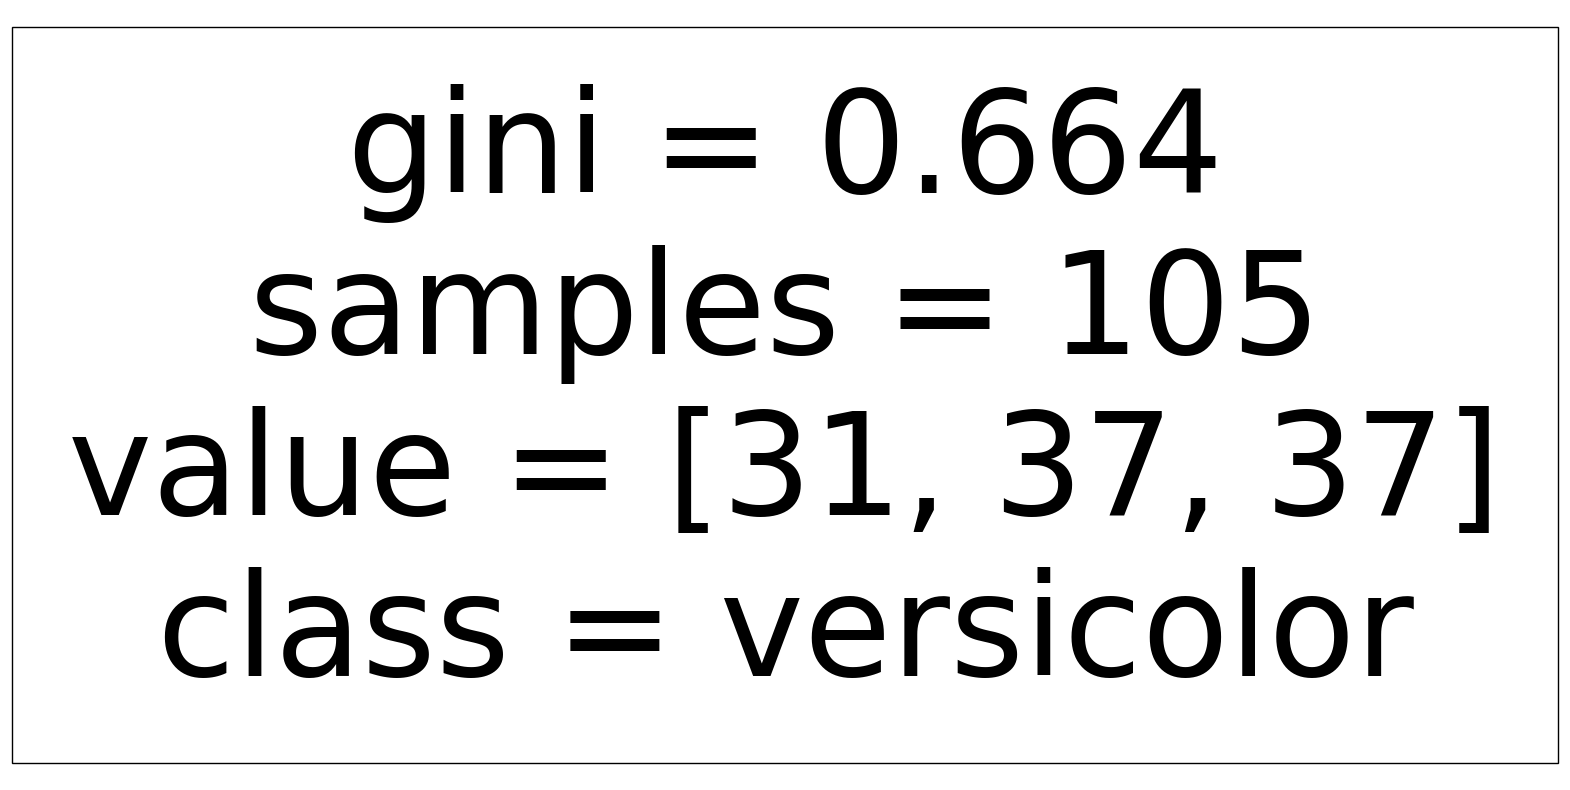

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 加载数据集
iris = load_iris()
X = iris.data
y = iris.target

# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 训练决策树模型
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# 成本复杂度剪枝参数
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# 对每个ccp_alpha训练一个决策树并评估其性能
trees = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    tree.fit(X_train, y_train)
    trees.append(tree)

# 选择最佳的ccp_alpha值（可根据测试集性能来选择）
# 这里简化了选择过程，实际应用中应该使用交叉验证等方法

# 可视化决策树
plt.figure(figsize=(20,10))
plot_tree(trees[-1], filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.draw()
plt.show()